# TP — Estadística Descriptiva sobre Dataset de Seguros Médicos

En el Módulo 1 trabajamos con este dataset enfocándonos en la **limpieza y manipulación de datos** con Pandas.  
En este TP retomamos el mismo dataset para hacer un **análisis estadístico completo**.

El objetivo es responder preguntas concretas sobre el comportamiento de los clientes usando las herramientas vistas en clase:
tendencia central, dispersión, sesgo, detección de outliers y correlación.

---

**Dataset:** seguros médicos de EE.UU.

| Columna | Descripción | Tipo |
|---|---|---|
| `age` | Edad del cliente | Numérica discreta |
| `sex` | Sexo | Categórica nominal |
| `bmi` | Índice de masa corporal | Numérica continua |
| `children` | Hijos incluidos en el seguro | Numérica discreta |
| `smoker` | ¿Fuma? (yes/no) | Categórica nominal |
| `region` | Región de EE.UU. | Categórica nominal |
| `charges` | Gastos médicos facturados (USD) | Numérica continua |

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

url = 'https://drive.google.com/uc?export=download&id=1leo0WjSbpwWOSTMUmCSMPsch3VindqYe'
df = pd.read_csv(url)

# Columna auxiliar de categoría BMI (ya la conocemos del módulo anterior)
bins   = [0, 18.5, 25, 30, float('inf')]
labels = ['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad']
df['bmi_category'] = pd.cut(df['bmi'], bins=bins, labels=labels, right=False)

# Codificamos smoker como variable binaria (útil para correlaciones)
df['smoker_num'] = (df['smoker'] == 'yes').astype(int)

print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dataset cargado: 1338 filas × 9 columnas


,age,sex,bmi,children,smoker,region,charges,bmi_category,smoker_num
0,19,female,27.900,0,yes,southwest,16884.92400,Sobrepeso,1
1,18,male,33.770,1,no,southeast,1725.55230,Obesidad,0
2,28,male,33.000,3,no,southeast,4449.46200,Obesidad,0
3,33,male,22.705,0,no,northwest,21984.47061,Normal,0
4,32,male,28.880,0,no,northwest,3866.85520,Sobrepeso,0


---
## PARTE 1 — Tendencia central: media, mediana y moda

La tendencia central nos dice dónde se concentran los datos.  
Comparar la **media** con la **mediana** es el primer indicador de si hay sesgo o valores extremos.

**Ejercicio 1.1** — Calculá la media, mediana y moda de `charges`, `bmi` y `age`.  
Organizá los resultados en un DataFrame con una fila por variable y columnas `media`, `mediana`, `moda`.

In [5]:
resumen = pd.DataFrame({
    'media'  : [df[c].mean()    for c in ['charges', 'bmi', 'age']],
    'mediana': [df[c].median()  for c in ['charges', 'bmi', 'age']],
    'moda'   : [df[c].mode()[0] for c in ['charges', 'bmi', 'age']]
}, index=['charges', 'bmi', 'age'])
resumen.round(2)


,media,mediana,moda
charges,13270.42,9382.03,1639.56
bmi,30.66,30.40,32.30
age,39.21,39.00,18.00


**Ejercicio 1.2** — Para la variable `charges`, graficá un histograma y marcá con líneas verticales la media y la mediana.  No olvides agregar leyendas, titulos/rotulos.
¿Qué relación observás entre los dos valores? ¿Qué te dice eso sobre la distribución?

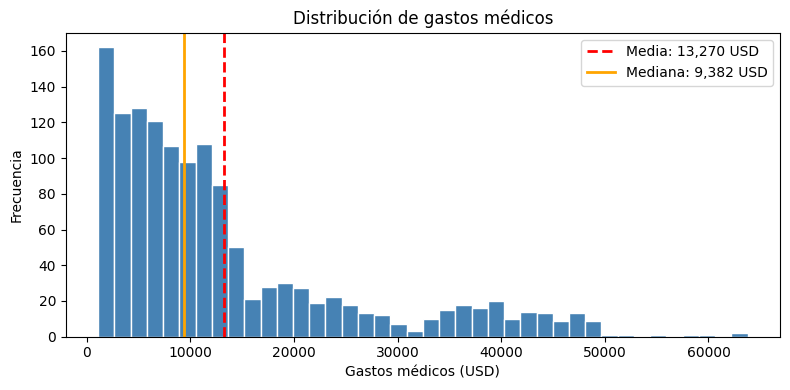

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['charges'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(df['charges'].mean(),   color='red',    linestyle='--',
           linewidth=2, label=f"Media: {df['charges'].mean():,.0f} USD")
ax.axvline(df['charges'].median(), color='orange', linestyle='-',
           linewidth=2, label=f"Mediana: {df['charges'].median():,.0f} USD")
ax.set_xlabel('Gastos médicos (USD)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de gastos médicos')
ax.legend()
plt.tight_layout()
plt.show()


*Observación:*  
La **media es mayor que la mediana**, lo que indica una distribución con **sesgo positivo** (cola hacia la derecha). Hay un grupo de clientes con gastos muy altos (probablemente fumadores o con enfermedades crónicas) que tiran la media hacia arriba. La mediana representa mejor el gasto 'típico' de la mayoría de los clientes.


**Ejercicio 1.3** — Calculá la media de `charges` por separado para fumadores y no fumadores.  
¿Cuántas veces más gasta en promedio un fumador que un no fumador?

In [7]:
media_por_fumador = df.groupby('smoker')['charges'].mean()
print(media_por_fumador)
ratio = media_por_fumador['yes'] / media_por_fumador['no']
print(f'\nUn fumador gasta en promedio {ratio:.1f}x más que un no fumador.')


smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

Un fumador gasta en promedio 3.8x más que un no fumador.


---
## PARTE 2 — Dispersión: varianza, desvío estándar e IQR

La dispersión mide cuán dispersos están los datos alrededor del centro.  
Un desvío alto indica mucha variabilidad; un IQR alto indica que el rango del 50% central es amplio.

**Ejercicio 2.1** — Calculá la varianza, el desvío estándar y el IQR de `charges` y `bmi`.  
¿En cuál de las dos variables hay mayor dispersión relativa?

In [8]:
for col in ['charges', 'bmi']:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    print(f'{col}:')
    print(f'  Varianza : {df[col].var():>12.2f}')
    print(f'  Desvío   : {df[col].std():>12.2f}')
    print(f'  IQR      : {iqr:>12.2f}')
    print()

# charges tiene mayor dispersión tanto en absoluto (desvío > 12000)
# como en relativo (coef. variacion = std/media > 1 en charges vs ~0.2 en bmi)


charges:
  Varianza : 146652372.15
  Desvío   :     12110.01
  IQR      :     11899.63

bmi:
  Varianza :        37.19
  Desvío   :         6.10
  IQR      :         8.40



**Ejercicio 2.2** — Calculá el desvío estándar de `charges` para fumadores y no fumadores por separado.  
¿Qué grupo tiene gastos más variables? ¿A qué creés que se debe?

In [9]:
desvio = df.groupby('smoker')['charges'].std()
print(desvio)


smoker
no      5993.781819
yes    11541.547176
Name: charges, dtype: float64


*Observación:*  
Los **fumadores** tienen gastos más variables. Dentro de ese grupo hay quienes gastan muy poco y quienes gastan enormemente (dependiendo de enfermedades asociadas al tabaco). Los no fumadores tienen un rango de gasto más predecible y acotado.


**Ejercicio 2.3** — Construí un boxplot comparativo de `charges` para fumadores vs. no fumadores.  
*Pista: usá `sns.boxplot()` con `x='smoker'` e `y='charges'`.*

C:\Users\Personal\AppData\Local\Temp\ipykernel_7928\1380500225.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, ax=ax, palette='Set2')


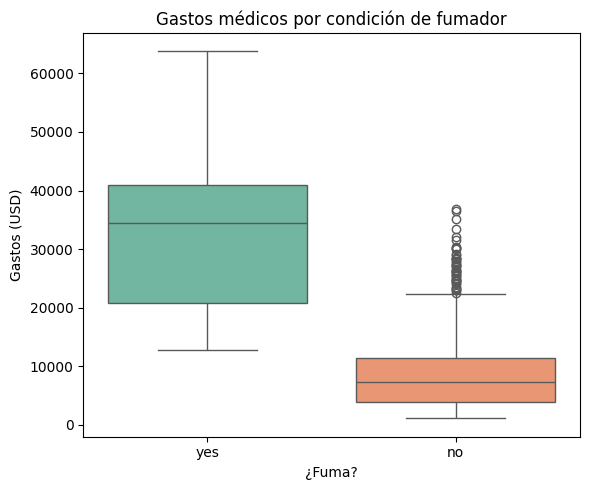

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(x='smoker', y='charges', data=df, ax=ax, palette='Set2')
ax.set_title('Gastos médicos por condición de fumador')
ax.set_xlabel('¿Fuma?')
ax.set_ylabel('Gastos (USD)')
plt.tight_layout()
plt.show()


---
## PARTE 3 — Sesgo (Skewness)

`df[columnas].skew()`

Calcula el coeficiente de asimetría (skewness) de cada columna numérica.
Un sesgo positivo indica cola a la derecha (valores extremos altos);  
un sesgo negativo indica cola a la izquierda.

| Skewness | Interpretación |
|---|---|
| ≈ 0 | Simétrica |
| > 0 | Cola derecha (sesgo positivo) |
| < 0 | Cola izquierda (sesgo negativo) |
| \|skew\| > 1 | Sesgo considerable |

**Ejercicio 3.1** — Calculá el sesgo de `charges`, `bmi` y `age`.  
¿Cuál tiene mayor asimetría? ¿En qué dirección?

In [11]:
for col in ['charges', 'bmi', 'age']:
    sk = df[col].skew()
    interpretacion = 'simétrica' if abs(sk) < 0.5 else ('sesgo positivo' if sk > 0 else 'sesgo negativo')
    print(f'{col:10s}: skewness = {sk:6.3f}  → {interpretacion}')


charges   : skewness =  1.516  → sesgo positivo
bmi       : skewness =  0.284  → simétrica
age       : skewness =  0.056  → simétrica


**Ejercicio 3.2** — Graficá los histogramas de `charges`, `bmi` y `age` en un subplot de 1×3.  
Marcá la media y la mediana en cada gráfico. ¿La posición relativa de media y mediana es consistente con el sesgo calculado?

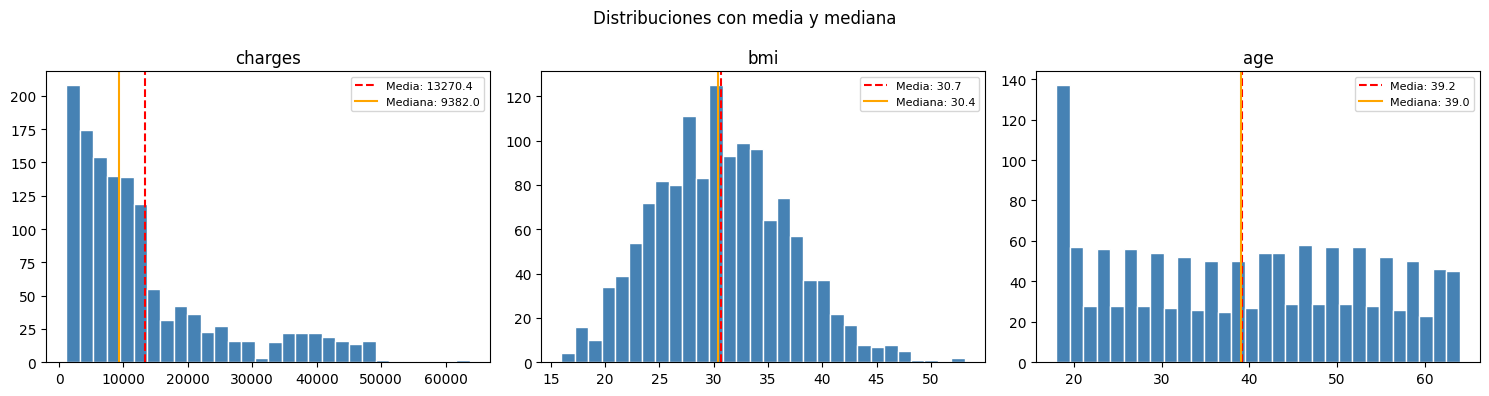

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['charges', 'bmi', 'age']):
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white')
    ax.axvline(df[col].mean(),   color='red',    linestyle='--',
               linewidth=1.5, label=f'Media: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='-',
               linewidth=1.5, label=f'Mediana: {df[col].median():.1f}')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Distribuciones con media y mediana')
plt.tight_layout()
plt.show()


*Observación:*  
- **charges** tiene la media desplazada hacia la derecha de la mediana → sesgo positivo alto.  
- **bmi** tiene media y mediana muy cercanas → casi simétrica.  
- **age** tiene la mediana ligeramente por debajo de la media → leve sesgo positivo.  
En los tres casos, **la media queda a la derecha de la mediana cuando hay sesgo positivo**, lo cual es consistente con los valores de skewness calculados.


---
## PARTE 4 — Detección de outliers

Vamos a identificar valores atípicos en `charges` y `bmi` usando dos métodos:  
**IQR** (robusto, funciona bien con distribuciones asimétricas) y **Z-score** (asume distribución normal).

**Ejercicio 4.1 — Método IQR sobre `charges`**

Calculá Q1, Q3 e IQR. Determiná los límites inferior y superior.  
¿Cuántos clientes tienen gastos atípicamente altos? ¿Son fumadores en su mayoría?

In [13]:
q1  = df['charges'].quantile(0.25)
q3  = df['charges'].quantile(0.75)
iqr = q3 - q1
lim_sup = q3 + 1.5 * iqr
lim_inf = q1 - 1.5 * iqr

outliers_charges = df[df['charges'] > lim_sup]

print(f'Q1 = {q1:,.0f}   Q3 = {q3:,.0f}   IQR = {iqr:,.0f}')
print(f'Límite superior: {lim_sup:,.0f}')
print(f'Outliers de alto costo: {len(outliers_charges)}')
print()
pct_fumadores = (outliers_charges['smoker'] == 'yes').mean() * 100
print(f'% de fumadores entre outliers: {pct_fumadores:.1f}%')
print(f'% de fumadores en todo el dataset: {(df["smoker"]=="yes").mean()*100:.1f}%')


Q1 = 4,740   Q3 = 16,640   IQR = 11,900
Límite superior: 34,489
Outliers de alto costo: 139

% de fumadores entre outliers: 97.8%
% de fumadores en todo el dataset: 20.5%


*Observación:*  
La gran mayoría de los clientes con gastos atípicamente altos son **fumadores**. Mientras que en el dataset total los fumadores son ~20%, entre los outliers de alto costo representan una proporción mucho mayor. Esto confirma que fumar es el factor que más empuja los gastos hacia valores extremos.


**Ejercicio 4.2 — Método Z-score sobre `bmi`**

Calculá el Z-score de cada cliente para `bmi`. Identificá los que tienen |z| > 3.  
Mostrá su `age`, `sex`, `bmi`, `smoker` y `charges`. ¿Hay algo en común entre ellos?

In [14]:
df['z_bmi'] = (df['bmi'] - df['bmi'].mean()) / df['bmi'].std()
outliers_bmi = df[df['z_bmi'].abs() > 3]

print(f'Outliers en BMI con |z| > 3: {len(outliers_bmi)}')
outliers_bmi[['age', 'sex', 'bmi', 'smoker', 'charges']]


Outliers en BMI con |z| > 3: 4


,age,sex,bmi,smoker,charges
116,58,male,49.06,no,11381.3254
847,23,male,50.38,no,2438.0552
1047,22,male,52.58,yes,44501.3982
1317,18,male,53.13,no,1163.4627


*Observación:*  
Los outliers de BMI son pocos y representan casos de **obesidad extrema** (BMI muy por encima de 30). No hay un patrón claro en cuanto a sexo o tabaquismo dentro de este pequeño grupo. Sus gastos médicos no son necesariamente los más altos del dataset, lo que sugiere que el BMI solo, sin la condición de fumador, no determina costos extremos.


**Ejercicio 4.3** — Graficá un boxplot de `bmi` para cada categoría de `bmi_category`.  
¿Se visualizan outliers dentro de alguna categoría?

C:\Users\Personal\AppData\Local\Temp\ipykernel_7928\3290314512.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


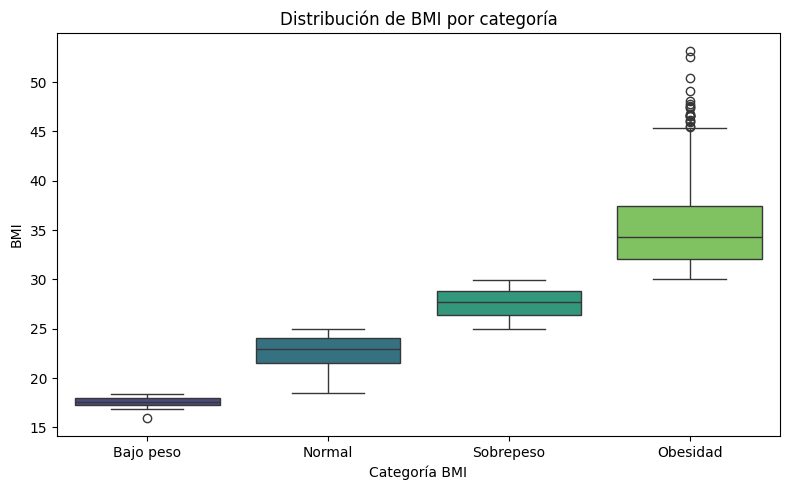

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    x='bmi_category', y='bmi', data=df, ax=ax,
    order=['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad'],
    palette='viridis'
)
ax.set_title('Distribución de BMI por categoría')
ax.set_xlabel('Categoría BMI')
ax.set_ylabel('BMI')
plt.tight_layout()
plt.show()


---
## PARTE 5 — Correlación

Vamos a medir la **fuerza y dirección de las relaciones** entre variables.

Recordá:
- **Pearson**: mide relaciones lineales entre variables cuantitativas continuas.
- **Spearman**: mide relaciones monótonas; adecuado para variables ordinales o cuando la relación no es lineal.
- Para correlacionar una variable **categórica binaria** (como `smoker`) con una numérica, la codificamos como 0/1 (ya está en `smoker_num`).

**Ejercicio 5.1 — Matriz de correlación de Pearson**

Calculá la correlación de Pearson entre todas las variables numéricas: `age`, `bmi`, `children`, `charges` y `smoker_num`.  
Mostrá la matriz y su heatmap.  
¿Qué variable tiene mayor correlación con `charges`?

              age    bmi  children  charges  smoker_num
age         1.000  0.109     0.042    0.299      -0.025
bmi         0.109  1.000     0.013    0.198       0.004
children    0.042  0.013     1.000    0.068       0.008
charges     0.299  0.198     0.068    1.000       0.787
smoker_num -0.025  0.004     0.008    0.787       1.000


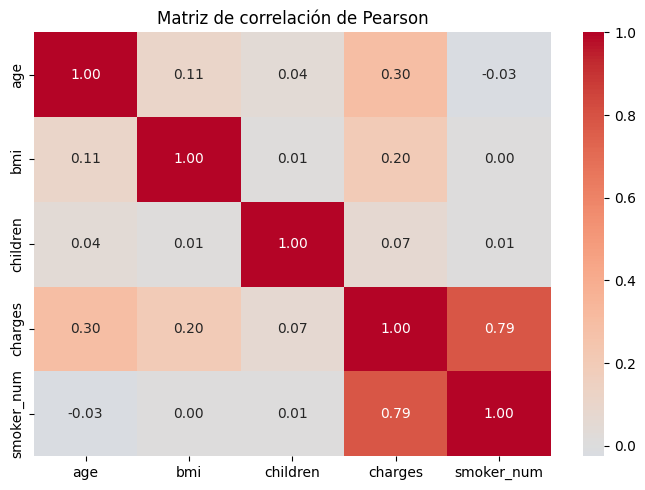

In [16]:
numericas = ['age', 'bmi', 'children', 'charges', 'smoker_num']
corr = df[numericas].corr()
print(corr.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matriz de correlación de Pearson')
plt.tight_layout()
plt.show()


*Observación:*  
La variable con **mayor correlación con `charges`** es **`smoker_num`** (r ≈ 0.79), lo que confirma que fumar es el predictor más potente del costo médico. `age` también tiene correlación positiva moderada (r ≈ 0.30), mientras que `bmi` y `children` tienen correlaciones más débiles.


**Ejercicio 5.2 — ¿Los fumadores tienen mayor BMI?**

Calculá la correlación de Pearson entre `smoker_num` y `bmi`.  
Luego graficá un boxplot de `bmi` separado por `smoker`.  
¿La correlación y el gráfico cuentan la misma historia?

Correlación Pearson smoker_num vs bmi: 0.0038


C:\Users\Personal\AppData\Local\Temp\ipykernel_7928\2601965494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='bmi', data=df, ax=ax, palette='Set1')


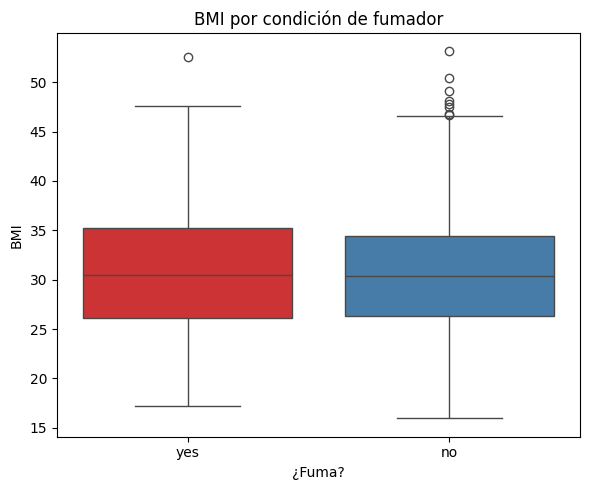

In [17]:
r_pearson = df['smoker_num'].corr(df['bmi'])
print(f'Correlación Pearson smoker_num vs bmi: {r_pearson:.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(x='smoker', y='bmi', data=df, ax=ax, palette='Set1')
ax.set_title('BMI por condición de fumador')
ax.set_xlabel('¿Fuma?')
ax.set_ylabel('BMI')
plt.tight_layout()
plt.show()


*Observación:*  
La correlación de Pearson entre `smoker_num` y `bmi` es **muy baja (≈ 0.0)**, lo que indica que fumar y el BMI son prácticamente independientes. El boxplot confirma esto: las distribuciones de BMI son casi idénticas entre fumadores y no fumadores. La historia es consistente: fumar no determina el peso corporal.


**Ejercicio 5.3 — Correlación de Spearman: `bmi_category` vs `charges`**

`bmi_category` es una variable **ordinal** (Bajo peso < Normal < Sobrepeso < Obesidad).  
Para trabajar con ella, convertila a valores numéricos (0, 1, 2, 3) usando el orden natural.

Calculá la correlación de Spearman entre `bmi_category_num` y `charges`.  
¿A mayor categoría de BMI, mayores gastos médicos?

In [18]:
from scipy import stats as sst

orden = {'Bajo peso': 0, 'Normal': 1, 'Sobrepeso': 2, 'Obesidad': 3}
df['bmi_category_num'] = df['bmi_category'].map(orden)

r_sp, p_sp = sst.spearmanr(df['bmi_category_num'], df['charges'])
print(f'Correlación de Spearman (bmi_category vs charges): r = {r_sp:.4f},  p = {p_sp:.4f}')


Correlación de Spearman (bmi_category vs charges): r = 0.1094,  p = 0.0001


*Observación:*  
Hay una **correlación positiva moderada** entre la categoría de BMI y los gastos médicos. A mayor categoría de BMI (de Normal a Obesidad), mayores son los gastos. La relación no es fortísima porque el tabaquismo también tiene un efecto dominante; un no fumador obeso puede gastar menos que un fumador de peso normal.


**Ejercicio 5.4 — Scatter: BMI vs Charges, coloreado por fumador**

Graficá un scatter plot de `bmi` (eje x) vs `charges` (eje y), usando un color diferente para fumadores y no fumadores.  
¿Qué patrón observás? ¿La relación entre BMI y gastos es la misma para ambos grupos?

*Pista: usá `hue='smoker'` en `sns.scatterplot()`.*

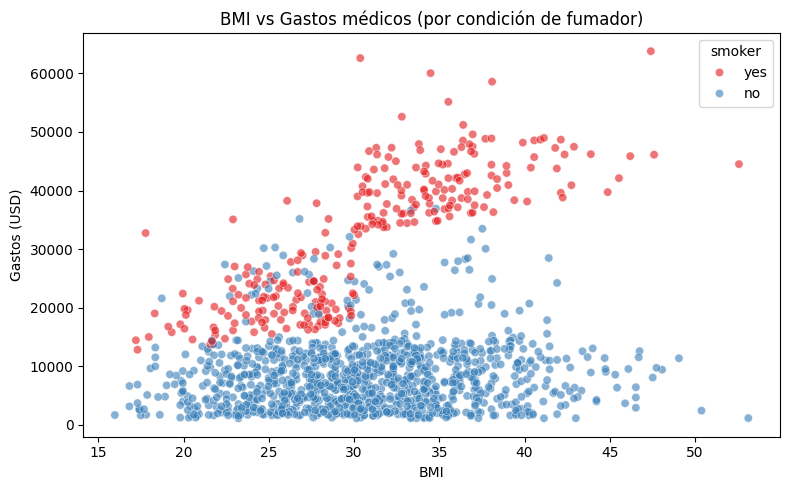

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df,
                ax=ax, alpha=0.6, palette='Set1')
ax.set_title('BMI vs Gastos médicos (por condición de fumador)')
ax.set_xlabel('BMI')
ax.set_ylabel('Gastos (USD)')
plt.tight_layout()
plt.show()


*Observación:*  
El scatter revela **dos nubes de puntos bien separadas**: los fumadores (rojo) están consistentemente por encima en gastos que los no fumadores (azul) para cualquier BMI. Además, dentro de los fumadores, a mayor BMI mayor gasto (tendencia visible). En los no fumadores esa tendencia es mucho más débil. La relación BMI–gastos es **mucho más fuerte en fumadores** que en no fumadores.


**Ejercicio 5.5 — Multicolinealidad**

Revisá la matriz de correlación calculada en 5.1. ¿Hay algún par de features con |r| > 0.5 entre sí (sin contar `charges`)?  
Si quisieras predecir `charges` con un modelo, ¿qué features conservarías y cuáles descartarías por ser redundantes?

In [20]:
print('Correlaciones > |0.5| (excluyendo charges):')
for i in numericas:
    for j in numericas:
        if i < j and i != 'charges' and j != 'charges':
            r = corr.loc[i, j]
            if abs(r) > 0.5:
                print(f'  {i} — {j}: r = {r:.2f}')

print()
print('Si no aparece ningún par, no hay multicolinealidad fuerte entre las features.')


Correlaciones > |0.5| (excluyendo charges):

Si no aparece ningún par, no hay multicolinealidad fuerte entre las features.


*Observación:*  
No hay multicolinealidad problemática entre las features predictoras (ningún par supera |r|=0.5 entre sí). Por lo tanto, si quisiéramos predecir `charges`, conservaríamos todas: **`smoker_num`, `age`, `bmi` y `children`** aportan información independiente y complementaria. Ninguna es redundante respecto de las otras.


---
## PARTE 6 — Análisis integrador

Usando todo lo aprendido, respondé las siguientes preguntas con código y una conclusión escrita.

**Pregunta 6.1 — ¿Cuál es el perfil estadístico del cliente de alto costo?**

Definí como "cliente de alto costo" a quienes tienen `charges` por encima del percentil 75.  
Para ese grupo, calculá: media de `age`, porcentaje de fumadores, media de `bmi` y región más frecuente.  
Compará con el grupo de bajo costo (por debajo del percentil 25).

In [21]:
p25 = df['charges'].quantile(0.25)
p75 = df['charges'].quantile(0.75)

alto_costo = df[df['charges'] > p75]
bajo_costo = df[df['charges'] < p25]

for etiqueta, grupo in [('ALTO COSTO (>P75)', alto_costo), ('BAJO COSTO (<P25)', bajo_costo)]:
    print(f'--- {etiqueta} ({len(grupo)} clientes) ---')
    print(f'  Edad media      : {grupo["age"].mean():.1f}')
    print(f'  % fumadores     : {(grupo["smoker"]=="yes").mean()*100:.1f}%')
    print(f'  BMI medio       : {grupo["bmi"].mean():.1f}')
    print(f'  Región más frec.: {grupo["region"].mode()[0]}')
    print()


--- ALTO COSTO (>P75) (335 clientes) ---
  Edad media      : 40.2
  % fumadores     : 76.1%
  BMI medio       : 31.3
  Región más frec.: southeast

--- BAJO COSTO (<P25) (335 clientes) ---
  Edad media      : 23.8
  % fumadores     : 0.0%
  BMI medio       : 29.9
  Región más frec.: southeast



*Conclusión:*  
El cliente de alto costo es típicamente **mayor, más frecuentemente fumador y con mayor BMI** que el de bajo costo. La diferencia más marcada es en el porcentaje de fumadores: en el grupo de alto costo es muy superior al del grupo de bajo costo. La región no muestra diferencias tan claras. Esto sugiere que las variables clave para predecir costos son edad, tabaquismo y BMI.


**Pregunta 6.2 — ¿El BMI es un predictor del gasto en fumadores pero no en no fumadores?**

Calculá la correlación de Pearson entre `bmi` y `charges` por separado para fumadores y no fumadores.  
Graficá un scatter para cada grupo con su línea de tendencia.  
¿La relación BMI–charges es más fuerte en uno de los dos grupos?

Correlación BMI-charges en fumadores:     r = 0.8065
Correlación BMI-charges en no fumadores:  r = 0.0840


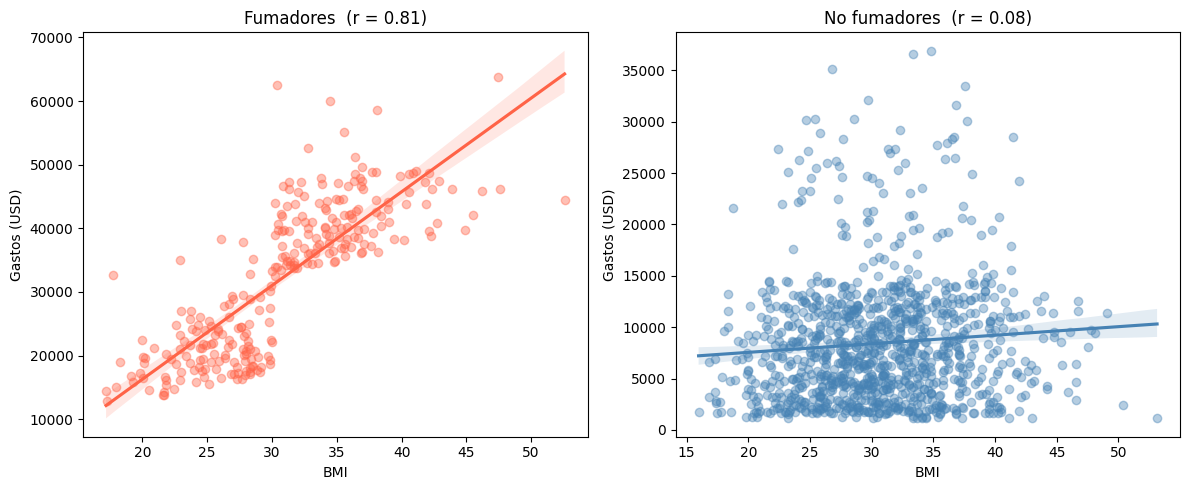

In [22]:
from scipy import stats as sst

fumadores    = df[df['smoker'] == 'yes']
no_fumadores = df[df['smoker'] == 'no']

r_fum,   _ = sst.pearsonr(fumadores['bmi'],    fumadores['charges'])
r_nofum, _ = sst.pearsonr(no_fumadores['bmi'], no_fumadores['charges'])
print(f'Correlación BMI-charges en fumadores:     r = {r_fum:.4f}')
print(f'Correlación BMI-charges en no fumadores:  r = {r_nofum:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, grupo, etiqueta, color, r in zip(
        axes,
        [fumadores, no_fumadores],
        ['Fumadores', 'No fumadores'],
        ['tomato', 'steelblue'],
        [r_fum, r_nofum]):
    sns.regplot(x='bmi', y='charges', data=grupo, ax=ax,
                scatter_kws={'alpha': 0.4, 'color': color},
                line_kws={'color': color})
    ax.set_title(f'{etiqueta}  (r = {r:.2f})')
    ax.set_xlabel('BMI')
    ax.set_ylabel('Gastos (USD)')
plt.tight_layout()
plt.show()


*Conclusión:*  
**Sí, el BMI es un predictor de gastos mucho más fuerte en fumadores** que en no fumadores. En los fumadores, a mayor BMI mayor gasto (correlación moderada-alta), probablemente porque la combinación de obesidad y tabaquismo genera enfermedades más costosas. En los no fumadores la relación es débil: el BMI solo, sin tabaquismo, tiene poco poder predictivo.


---
## Conclusión general

Redactá un párrafo breve respondiendo: **¿cuáles son los factores que más influyen en los gastos médicos según tu análisis estadístico?**  
Apoyate en los valores calculados (correlaciones, medias, porcentajes) para justificar tu respuesta.

*Conclusión general:*  

Según el análisis estadístico completo, los factores que más influyen en los gastos médicos son, en orden de importancia: **1) Fumar** (correlación con charges ≈ 0.79, diferencia de medias >3x), **2) Edad** (correlación moderada-positiva ≈ 0.30; a más edad, más gastos), y **3) BMI** (efecto amplificado en fumadores). La región y el número de hijos tienen impacto estadístico mínimo. La combinación de fumador + obesidad es el perfil de mayor riesgo económico para la aseguradora.
